<a href="https://colab.research.google.com/github/Andrew-lee0615/Quant-Analysis-Python/blob/main/03_spy_emb_correlation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  3 of 3 completed


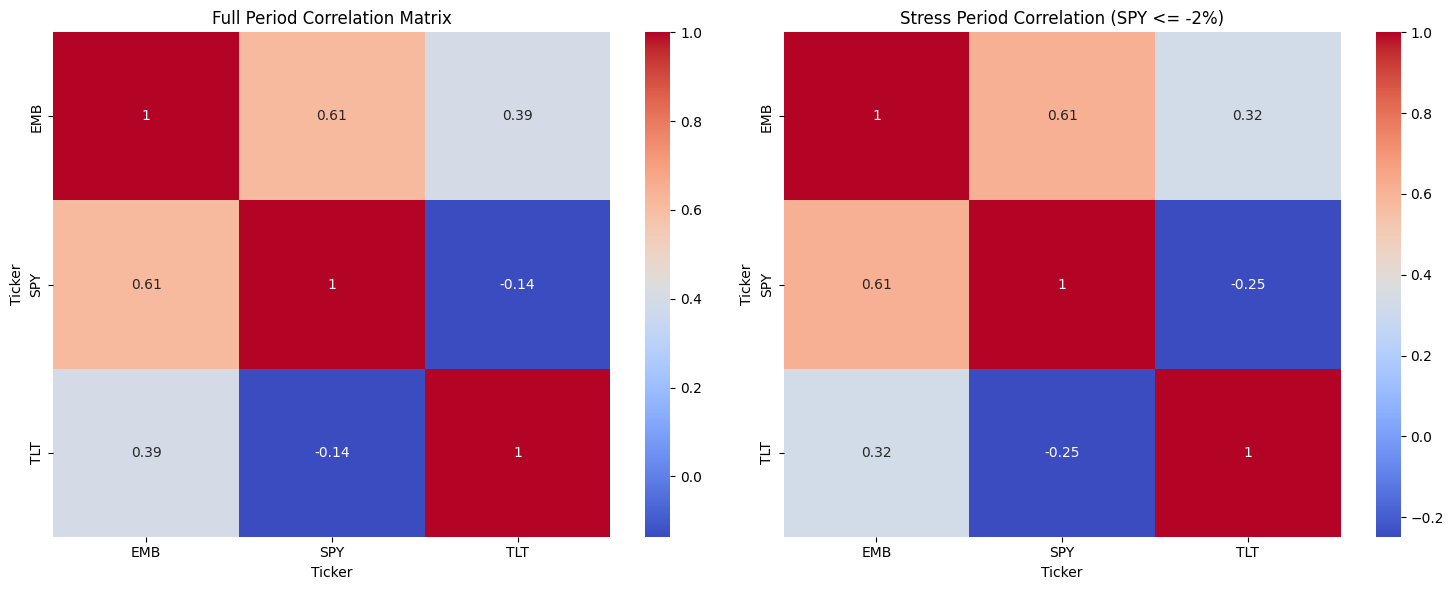

------------------------------
Correlation Analysis Results
------------------------------
Full Period SPY-EMB Corr: 0.6111
Stress Period SPY-EMB Corr: 0.6125
Stress Period SPY-TLT Corr: -0.2484
------------------------------


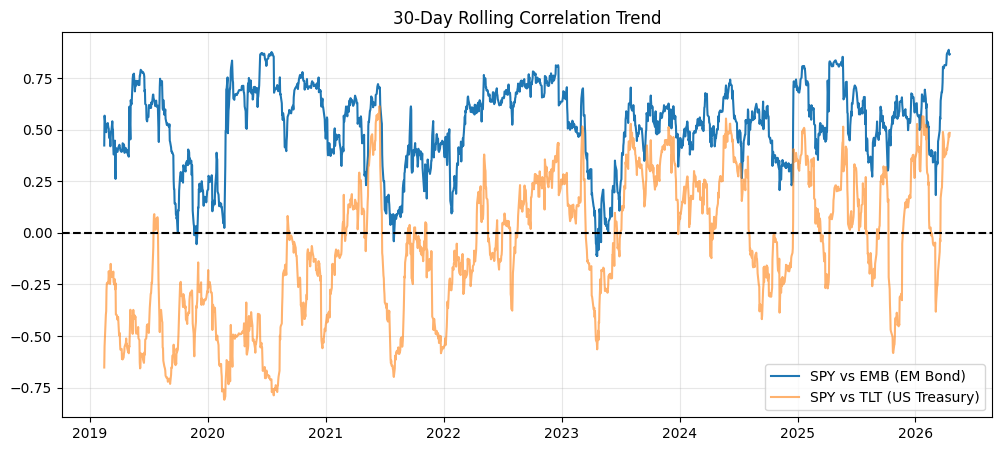

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download Data
# Added auto_adjust=True to handle the FutureWarning
# Using ['Close'] because auto_adjust=True merges Adjusted Close into Close
assets = ['SPY', 'EMB', 'TLT']
raw_data = yf.download(assets, start="2019-01-01", auto_adjust=True)

# Select 'Close' price for all assets
data = raw_data['Close']

# 2. Calculate Daily Returns
returns = data.pct_change().dropna()

# 3. Full Period Correlation Matrix
full_corr = returns.corr()

# 4. Filter 'Stress Period' (Days when SPY return <= -0.02)
stress_days = returns[returns['SPY'] <= -0.02]
stress_corr = stress_days.corr()

# 5. Visualization: Full Period vs. Stress Period
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(full_corr, annot=True, cmap='coolwarm', ax=ax[0])
ax[0].set_title('Full Period Correlation Matrix')

sns.heatmap(stress_corr, annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Stress Period Correlation (SPY <= -2%)')

plt.tight_layout()
plt.show()

# 6. Print Statistical Summary
print("-" * 30)
print("Correlation Analysis Results")
print("-" * 30)
print(f"Full Period SPY-EMB Corr: {full_corr.loc['SPY', 'EMB']:.4f}")
print(f"Stress Period SPY-EMB Corr: {stress_corr.loc['SPY', 'EMB']:.4f}")
print(f"Stress Period SPY-TLT Corr: {stress_corr.loc['SPY', 'TLT']:.4f}")
print("-" * 30)

# 7. 30-Day Rolling Correlation Trend
rolling_corr_emb = returns['SPY'].rolling(window=30).corr(returns['EMB'])
rolling_corr_tlt = returns['SPY'].rolling(window=30).corr(returns['TLT'])

plt.figure(figsize=(12, 5))
plt.plot(rolling_corr_emb, label='SPY vs EMB (EM Bond)')
plt.plot(rolling_corr_tlt, label='SPY vs TLT (US Treasury)', alpha=0.6)
plt.axhline(0, color='black', linestyle='--')
plt.title('30-Day Rolling Correlation Trend')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## - Conclusion & Quantitative Critique

### 1. Empirical Results
* **Full Period SPY-EMB Correlation:** 0.6111
* **Stress Period SPY-EMB Correlation:** 0.6125
* **Stress Period SPY-TLT Correlation:** -0.2484

### 2. Analysis & Critique of WSJ Thesis
Contrary to the WSJ podcast's claim that EM bonds serve as a superior hedge, the empirical data from 2019-2026 suggests a more nuanced reality:
* **Failure of Decoupling:** The correlation between SPY and EMB remained consistently positive (~0.61) even during market stress. This indicates that EMB still carries significant **systematic risk** and does not provide an independent "Safe Haven" effect during liquidity crunches.
* **Superiority of Treasuries (TLT):** During the observed stress periods, $TLT$ maintained a negative correlation (-0.24), proving it was a more effective hedge against equity drawdowns than $EMB$.
* **Final Verdict:** The "Positive Terms of Trade" argument for EM bonds might offer yield (Carry), but it does not guarantee protection during acute market shocks. Diversification into EM debt should be viewed as a **Yield-Enhancement** strategy rather than a pure **Tail-Risk Hedge**.